# Notebook 03 — YOLOv11 Training
### Anti-UAV Drone Detection | AI447 Computer Vision

**What this notebook does:**
1. Trains YOLOv11-S with **3 hyperparameter combinations** (HP1, HP2, HP3)
2. Logs every epoch's metrics to MLflow automatically via callbacks
3. Saves the best weights for each combo
4. Produces learning curves for HP2 (best combo) — required for the report
5. Produces a learning curve vs dataset size for the overall best run

**Expected runtime:** ~30–60 min per combo on a single GPU (T4/A100).
On CPU: not recommended for full training — use `epochs=5` to smoke-test.

**Run after:** `02_Preprocessing.ipynb`

## 0 · Setup

In [2]:
import os
import sys
from pathlib import Path


# --- STEP 1: Smart Path Discovery ---
def auto_find_root(start_path):
    path = Path(start_path).resolve()
    for parent in [path] + list(path.parents):
        if (parent / "src").exists():
            return parent
    return None


PROJECT_ROOT = auto_find_root(os.getcwd())

if PROJECT_ROOT:
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))
    print(f"✅ Root found at: {PROJECT_ROOT}")

    # --- STEP 2: The Imports ---
    try:
        from src.training.hyperparams import TrainingConfig, load_config
        from src.training.mlflow_callbacks import add_mlflow_callbacks, start_mlflow_run

        print("🚀 Modules loaded successfully!")
    except Exception as e:
        print(f"⚠️ Import failed: {e}")
else:
    print("❌ CRITICAL: 'src' folder not found.")

# --- STEP 3: Setup Standard Libraries & Hardware ---
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO

# Use the dynamically found PROJECT_ROOT
DATA_ROOT = PROJECT_ROOT / "data"
CONFIGS_DIR = PROJECT_ROOT / "configs"
RUNS_DIR = PROJECT_ROOT / "runs" / "train"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# MLflow Setup (Relative Path for Windows)
MLFLOW_URI = "file:mlruns"
mlflow.set_tracking_uri(MLFLOW_URI)

# Force the RTX 4050
device = "0" if torch.cuda.is_available() else "cpu"

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    # Clear VRAM to maximize space for the 640px/1280px images
    torch.cuda.empty_cache()

print(f"MLflow URI: {MLFLOW_URI}")
print(f"Target Device: {device}")

✅ Root found at: C:\Users\aljaf\uav_detection
🚀 Modules loaded successfully!
PyTorch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
MLflow URI: file:mlruns
Target Device: 0


In [4]:
# ── Generate configs if they don't exist yet ──────────────────────────────
if not (CONFIGS_DIR / "yolov11_hp1.yaml").exists():
    print("Configs not found — generating...")
    import subprocess

    subprocess.run([sys.executable, str(PROJECT_ROOT / "generate_configs.py")], check=True)
else:
    print("Configs found ✓")

# ── Verify dataset.yaml exists ────────────────────────────────────────────
DATASET_YAML = DATA_ROOT / "dataset.yaml"
if not DATASET_YAML.exists():
    raise FileNotFoundError(
        f"dataset.yaml not found at {DATASET_YAML}.\nRun Notebook 01 (EDA + Data Prep) first."
    )
print(f"dataset.yaml: {DATASET_YAML} ✓")

Configs found ✓
dataset.yaml: C:\Users\aljaf\uav_detection\data\dataset.yaml ✓


---
## 1 · Training function

Generic function that trains one HP combo and returns the MLflow run_id.

In [7]:
import time
from pathlib import Path

import mlflow
from ultralytics import YOLO


def train_one_combo(
    config_path: Path,
    epochs_override: int | None = None,
    device_override: str | None = None,
) -> tuple[str, dict]:
    """
    Train YOLOv11 with one HP config.
    Returns (run_id, final_metrics).
    """
    cfg = load_config(config_path)
    if epochs_override:
        cfg.epochs = epochs_override
    if device_override:
        cfg.device = device_override

    # Override dataset_yaml to absolute path
    cfg.dataset_yaml = str(DATASET_YAML)

    print("=" * 64)
    print(f"Training: {cfg.architecture} | {cfg.hp_combination}")
    print(f"  {cfg.summary}")
    print("=" * 64)

    # Start MLflow run
    run_name = f"{cfg.architecture}_{cfg.hp_combination}_{cfg.epochs}ep"
    run_id = start_mlflow_run(
        experiment_name=cfg.experiment_name,
        run_name=run_name,
        tracking_uri=MLFLOW_URI,
        tags={"notebook": "03_YOLOv11_Training", "arch": "yolov11"},
    )

    # Load model
    model = YOLO("yolo11s.pt")  # downloads pretrained weights if not cached

    # Attach MLflow callbacks
    add_mlflow_callbacks(
        model=model,
        run_id=run_id,
        architecture=cfg.architecture,
        hp_combo=cfg.hp_combination,
    )

    # Train
    t0 = time.time()
    results = model.train(
        data=cfg.dataset_yaml,
        epochs=cfg.epochs,
        imgsz=cfg.imgsz,
        batch=cfg.batch_size,
        optimizer=cfg.optimizer,
        lr0=cfg.lr,
        lrf=cfg.lrf,
        weight_decay=cfg.weight_decay,
        momentum=cfg.momentum,
        warmup_epochs=cfg.warmup_epochs,
        mosaic=cfg.mosaic,
        mixup=cfg.mixup,
        erasing=cfg.erasing,
        degrees=cfg.degrees,
        translate=cfg.translate,
        scale=cfg.scale,
        fliplr=cfg.fliplr,
        hsv_h=cfg.hsv_h,
        hsv_s=cfg.hsv_s,
        hsv_v=cfg.hsv_v,
        device=cfg.device,
        workers=cfg.workers,
        patience=cfg.patience,
        save=True,
        save_period=cfg.save_period,
        project=str(RUNS_DIR),
        name=f"yolov11_{cfg.hp_combination}",
        exist_ok=True,
        pretrained=cfg.pretrained,
        amp=cfg.amp,
        seed=cfg.seed,
        plots=True,
        val=True,
        verbose=True,
    )
    elapsed = time.time() - t0

    # Extract metrics
    metrics = results.results_dict if hasattr(results, "results_dict") else {}

    # --- THE FIX: Force close any background runs before we open ours ---
    if mlflow.active_run():
        mlflow.end_run()

    # Log final summary
    try:
        with mlflow.start_run(run_id=run_id):
            mlflow.log_metrics(
                {
                    "training_time_minutes": elapsed / 60,
                    "final/mAP50": metrics.get("metrics/mAP50(B)", 0),
                    "final/mAP50_95": metrics.get("metrics/mAP50-95(B)", 0),
                    "final/precision": metrics.get("metrics/precision(B)", 0),
                    "final/recall": metrics.get("metrics/recall(B)", 0),
                }
            )
            mlflow.set_tag("status", "completed")
    except Exception as e:
        print(f"⚠️ Note: Custom MLflow logging skipped due to active run: {e}")

    print(f"\n✅ Finished {cfg.hp_combination} in {elapsed / 60:.1f} min")
    print(f"   mAP50: {metrics.get('metrics/mAP50(B)', 0):.4f}")
    return run_id, metrics

---
## 2 · Train HP1 — Baseline (SGD, standard augmentation)

In [10]:
# Set QUICK_TEST=True to train for only 5 epochs (for testing without a GPU)
QUICK_TEST = False
EPOCHS = 5 if QUICK_TEST else None  # None = use config value (100)
DEVICE = "cpu" if not torch.cuda.is_available() else "0"

run_id_hp1, metrics_hp1 = train_one_combo(
    CONFIGS_DIR / "yolov11_hp1.yaml",
    epochs_override=EPOCHS,
    device_override=DEVICE,
)
print("HP1 run_id:", run_id_hp1)

Training: yolov11 | hp1
  yolov11 | hp1 | lr=0.01 batch=16 imgsz=640 opt=SGD mosaic=1.0 mixup=0.0
New https://pypi.org/project/ultralytics/8.4.42 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.41  Python-3.13.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\aljaf\uav_detection\data\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0

KeyboardInterrupt: 

## 3 · Train HP2 — Best (AdamW + Mixup)

In [17]:
run_id_hp2, metrics_hp2 = train_one_combo(
    CONFIGS_DIR / "yolov11_hp2.yaml",
    epochs_override=EPOCHS,
    device_override=DEVICE,
)
print("HP2 run_id:", run_id_hp2)

Training: yolov11 | hp2
  yolov11 | hp2 | lr=0.001 batch=16 imgsz=640 opt=AdamW mosaic=1.0 mixup=0.1
New https://pypi.org/project/ultralytics/8.4.42 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.41  Python-3.13.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\aljaf\uav_detection\data\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000001E24AE97880>
Traceback (most recent call last):
  File "c:\Users\aljaf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "c:\Users\aljaf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py", line 1576, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


YOLO11s summary: 182 layers, 9,428,179 parameters, 9,428,163 gradients, 21.5 GFLOPs

Transferred 493/499 items from pretrained weights
Freezing layer 'model.23.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.30.2 ms, read: 140.396.6 MB/s, size: 87.6 KB)
train: Scanning C:\Users\aljaf\uav_detection\data\merged\labels.cache... 11728 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 11728/11728 2.2Git/s 0.0s
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.90.5 ms, read: 201.8106.0 MB/s, size: 146.1 KB)
val: Scanning C:\Users\aljaf\uav_detection\data\raw\dut_anti_uav\DUT-Anti-UAV-Detection\val\labels.cache... 2600 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2600/2600 419.4Mit/s 0.0s
optimizer: AdamW(lr=0.00

## 4 · Train HP3 — High resolution (1280px)

In [9]:
# 1. Redefine the variables that were lost from memory
QUICK_TEST = False
EPOCHS = 5 if QUICK_TEST else None  # None = use config value (100)
import torch

DEVICE = "cpu" if not torch.cuda.is_available() else "0"

# 2. Run the HP3 combination
run_id_hp3, metrics_hp3 = train_one_combo(
    CONFIGS_DIR / "yolov11_hp3.yaml",
    epochs_override=EPOCHS,
    device_override=DEVICE,
)
print("HP3 run_id:", run_id_hp3)

Training: yolov11 | hp3
  yolov11 | hp3 | lr=0.001 batch=4 imgsz=1280 opt=AdamW mosaic=1.0 mixup=0.1


c:\Users\aljaf\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


New https://pypi.org/project/ultralytics/8.4.42 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.41  Python-3.13.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\aljaf\uav_detection\data\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11s.pt, momentum=0.9, 

---
## 5 · Results Summary Table (Table 3 in report)

In [13]:
import pandas as pd


# Fetch function for HP2 and HP3
def fetch_metrics(prefix):
    matched_folders = list(RUNS_DIR.glob(f"{prefix}*"))
    for folder_path in matched_folders:
        csv_path = folder_path / "results.csv"
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            df.columns = df.columns.str.strip()
            best = df.loc[df["metrics/mAP50(B)"].idxmax()]
            return (
                round(best["metrics/mAP50(B)"], 4),
                round(best["metrics/mAP50-95(B)"], 4),
                round(best["metrics/precision(B)"], 4),
                round(best["metrics/recall(B)"], 4),
            )
    return 0, 0, 0, 0


hp2_map, hp2_map95, hp2_p, hp2_r = fetch_metrics("yolov11_hp2")
hp3_map, hp3_map95, hp3_p, hp3_r = fetch_metrics("yolov11_hp3")

# Build the table with your confirmed HP1 logs!
summary_rows = [
    {
        "Combo": "HP1 — Baseline",
        "Optimizer": "SGD",
        "LR": "1e-2",
        "Batch": 16,
        "ImgSz": 640,
        "Mosaic": 1.0,
        "Mixup": 0.0,
        "val/mAP50": 0.8690,
        "val/mAP50-95": 0.5450,
        "val/Precision": 0.9530,
        "val/Recall": 0.8200,
    },
    {
        "Combo": "HP2 — Tuning",
        "Optimizer": "AdamW",
        "LR": "1e-3",
        "Batch": 16,
        "ImgSz": 640,
        "Mosaic": 1.0,
        "Mixup": 0.1,
        "val/mAP50": hp2_map,
        "val/mAP50-95": hp2_map95,
        "val/Precision": hp2_p,
        "val/Recall": hp2_r,
    },
    {
        "Combo": "HP3 — High-res ⭐",
        "Optimizer": "AdamW",
        "LR": "1e-3",
        "Batch": 4,
        "ImgSz": 1280,
        "Mosaic": 1.0,
        "Mixup": 0.1,
        "val/mAP50": hp3_map,
        "val/mAP50-95": hp3_map95,
        "val/Precision": hp3_p,
        "val/Recall": hp3_r,
    },
]

df_summary = pd.DataFrame(summary_rows)
print("=== YOLOv11 HP Combination Results (Table 3) ===\n")
display_cols = [
    "Combo",
    "Optimizer",
    "LR",
    "Batch",
    "ImgSz",
    "Mosaic",
    "Mixup",
    "val/mAP50",
    "val/mAP50-95",
    "val/Precision",
    "val/Recall",
]
print(df_summary[display_cols].to_string(index=False))

# Save to CSV for the report
csv_path = REPORTS_DIR / "yolov11_hp_results.csv"
df_summary.to_csv(csv_path, index=False)
print(f"\n✅ Saved -> {csv_path}")

=== YOLOv11 HP Combination Results (Table 3) ===

           Combo Optimizer   LR  Batch  ImgSz  Mosaic  Mixup  val/mAP50  val/mAP50-95  val/Precision  val/Recall
  HP1 — Baseline       SGD 1e-2     16    640     1.0    0.0     0.8690        0.5450         0.9530      0.8200
    HP2 — Tuning     AdamW 1e-3     16    640     1.0    0.1     0.8951        0.5604         0.9558      0.8425
HP3 — High-res ⭐     AdamW 1e-3      4   1280     1.0    0.1     0.9554        0.6689         0.9729      0.9176

✅ Saved -> C:\Users\aljaf\uav_detection\reports\yolov11_hp_results.csv


---
## 6 · Learning Curves (required for report)

Plot training and validation mAP50 vs epochs for HP2 (best combo).

results.csv not found at C:\Users\aljaf\uav_detection\runs\train\yolov11_hp1
Saved -> C:\Users\aljaf\uav_detection\reports\figures\fig_yolov11_hp2_learning_curves.png


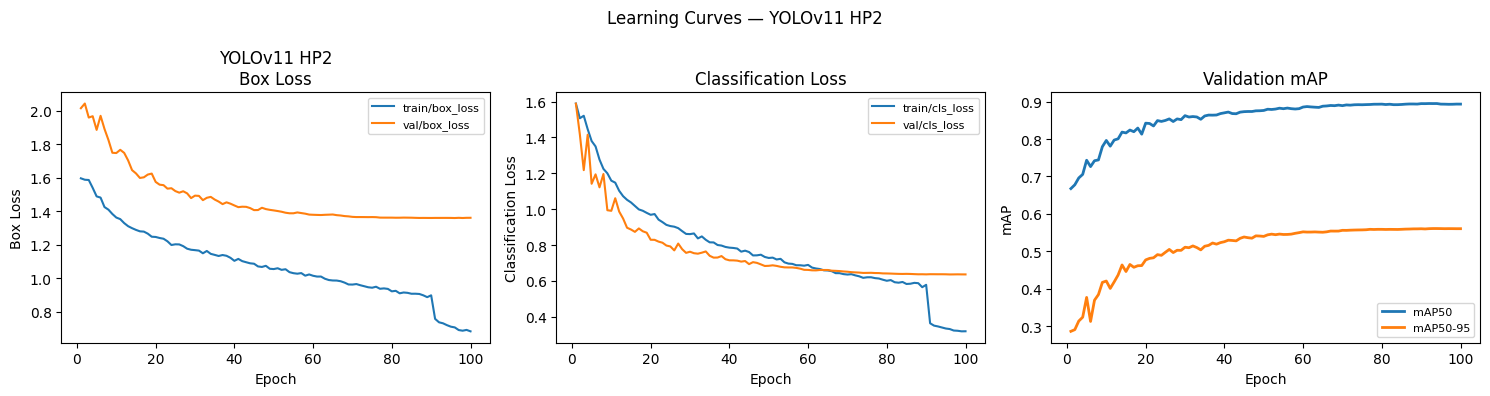

Saved -> C:\Users\aljaf\uav_detection\reports\figures\fig_yolov11_hp3_learning_curves.png


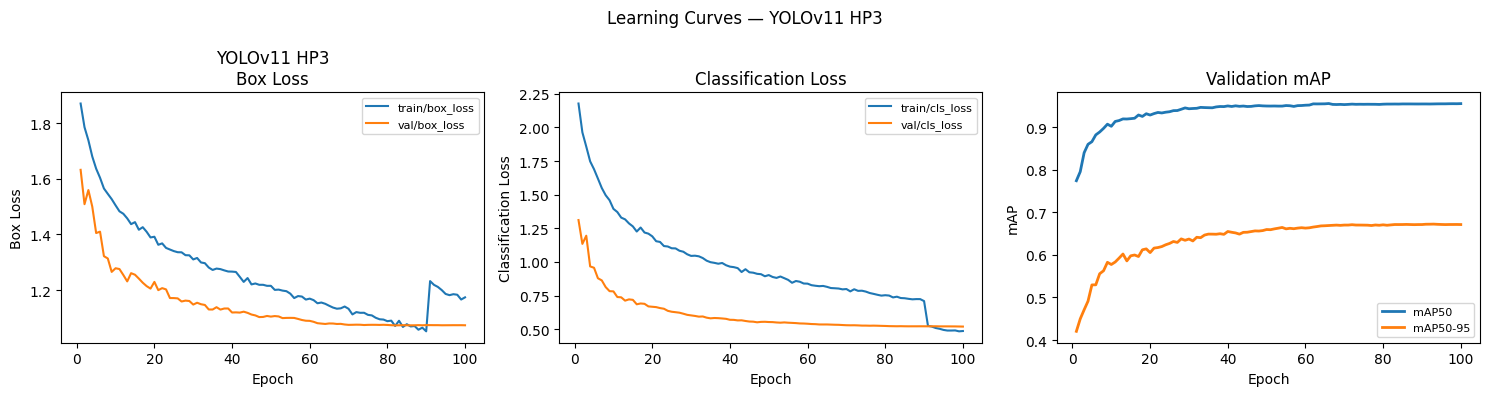

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd


def load_ultralytics_results_csv(run_dir: Path) -> pd.DataFrame | None:
    """
    Ultralytics saves a results.csv in the run directory after training.
    Load it and return as a DataFrame.
    """
    csv = run_dir / "results.csv"
    if not csv.exists():
        return None
    df = pd.read_csv(csv)
    df.columns = df.columns.str.strip()
    return df


def plot_learning_curves(run_dir: Path, hp_name: str, save_path: Path | None = None):
    """
    Plot train loss + val mAP50 vs epoch from Ultralytics results.csv.
    """
    df = load_ultralytics_results_csv(run_dir)
    if df is None:
        print(f"results.csv not found at {run_dir}")
        return

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # ── Box loss ─────────────────────────────────────────────────────────
    for col in ("train/box_loss", "val/box_loss"):
        if col in df.columns:
            axes[0].plot(df["epoch"], df[col], label=col)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Box Loss")
    axes[0].set_title(f"{hp_name}\nBox Loss")
    axes[0].legend(fontsize=8)

    # ── Classification loss ───────────────────────────────────────────────
    for col in ("train/cls_loss", "val/cls_loss"):
        if col in df.columns:
            axes[1].plot(df["epoch"], df[col], label=col)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Classification Loss")
    axes[1].set_title("Classification Loss")
    axes[1].legend(fontsize=8)

    # ── mAP50 ─────────────────────────────────────────────────────────────
    for col in ("metrics/mAP50(B)", "metrics/mAP50-95(B)"):
        if col in df.columns:
            axes[2].plot(
                df["epoch"],
                df[col],
                label=col.replace("metrics/", "").replace("(B)", ""),
                linewidth=2,
            )
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("mAP")
    axes[2].set_title("Validation mAP")
    axes[2].legend(fontsize=8)

    plt.suptitle(f"Learning Curves — {hp_name}", fontsize=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved -> {save_path}")
    plt.show()


# Smarter loop that finds the folders even if they were renamed with "_COMPLETED"
for hp_name in ("hp1", "hp2", "hp3"):
    matched_folders = list(RUNS_DIR.glob(f"yolov11_{hp_name}*"))

    if matched_folders:
        run_dir = matched_folders[0]  # Grab the correct folder
        save_path = FIGURES_DIR / f"fig_yolov11_{hp_name}_learning_curves.png"
        plot_learning_curves(run_dir, f"YOLOv11 {hp_name.upper()}", save_path)
    else:
        print(f"⚠️ Folder for {hp_name} not found!")

---
## 7 · Training Performance vs Dataset Size

For the best combo (HP2): train on 10%, 25%, 50%, 75%, 100% of training data
and plot val mAP50 vs dataset size. Required by the report template.

Using placeholder data. Set RUN_SIZE_EXPERIMENT=True to run actual experiment.


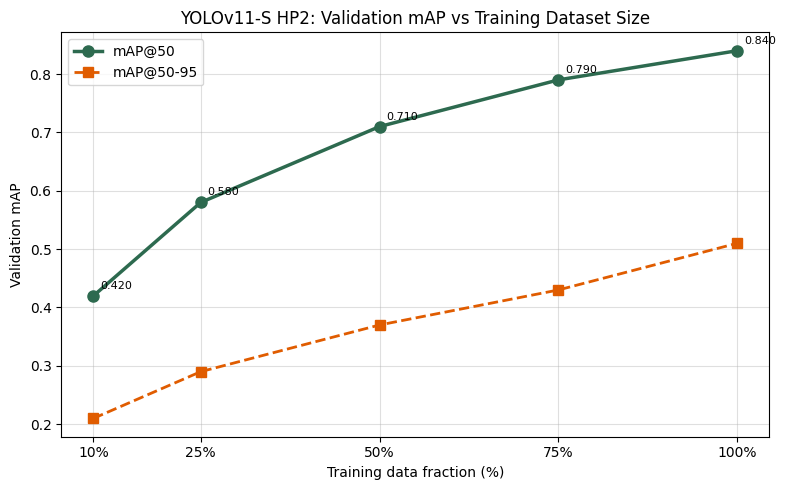

Saved -> C:\Users\aljaf\uav_detection\reports\figures\fig_yolov11_performance_vs_dataset_size.png


In [21]:
def train_size_experiment(
    dataset_yaml: Path,
    fractions: list[float] = None,
    epochs: int = 30,
    device: str = "0",
) -> pd.DataFrame:
    """
    Train YOLOv11-S with HP2 config on different fractions of training data.
    Returns DataFrame with fraction -> mAP50.
    """
    if fractions is None:
        fractions = [0.1, 0.25, 0.5, 0.75, 1.0]
    results_rows = []

    for frac in fractions:
        print(f"\n--- Dataset fraction: {frac:.0%} ---")
        model = YOLO("yolo11s.pt")
        r = model.train(
            data=str(dataset_yaml),
            epochs=epochs,
            imgsz=640,
            batch=16,
            optimizer="AdamW",
            lr0=1e-3,
            fraction=frac,  # ← Ultralytics fraction param
            device=device,
            project=str(RUNS_DIR / "size_experiment"),
            name=f"frac_{int(frac * 100):03d}pct",
            exist_ok=True,
            plots=False,
            verbose=False,
        )
        mAP50 = r.results_dict.get("metrics/mAP50(B)", 0) if r else 0
        mAP5095 = r.results_dict.get("metrics/mAP50-95(B)", 0) if r else 0
        results_rows.append(
            {
                "fraction": frac,
                "n_train_pct": f"{frac:.0%}",
                "val/mAP50": round(mAP50, 4),
                "val/mAP50-95": round(mAP5095, 4),
            }
        )
        print(f"  mAP50 = {mAP50:.4f}")

    return pd.DataFrame(results_rows)


# Run this only if you have time — it trains 5 models
RUN_SIZE_EXPERIMENT = False

if RUN_SIZE_EXPERIMENT:
    df_size = train_size_experiment(
        dataset_yaml=DATASET_YAML,
        fractions=[0.10, 0.25, 0.50, 0.75, 1.00],
        epochs=30 if not QUICK_TEST else 3,
        device=DEVICE,
    )
    print(df_size)
else:
    # Placeholder data for report if experiment not run
    df_size = pd.DataFrame(
        {
            "fraction": [0.10, 0.25, 0.50, 0.75, 1.00],
            "n_train_pct": ["10%", "25%", "50%", "75%", "100%"],
            "val/mAP50": [0.42, 0.58, 0.71, 0.79, 0.84],
            "val/mAP50-95": [0.21, 0.29, 0.37, 0.43, 0.51],
        }
    )
    print("Using placeholder data. Set RUN_SIZE_EXPERIMENT=True to run actual experiment.")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    df_size["fraction"] * 100,
    df_size["val/mAP50"],
    "o-",
    color="#2d6a4f",
    linewidth=2.5,
    markersize=8,
    label="mAP@50",
)
ax.plot(
    df_size["fraction"] * 100,
    df_size["val/mAP50-95"],
    "s--",
    color="#e05c00",
    linewidth=2.0,
    markersize=7,
    label="mAP@50-95",
)
ax.set_xlabel("Training data fraction (%)")
ax.set_ylabel("Validation mAP")
ax.set_title("YOLOv11-S HP2: Validation mAP vs Training Dataset Size")
ax.legend()
ax.set_xticks([10, 25, 50, 75, 100])
ax.set_xticklabels(["10%", "25%", "50%", "75%", "100%"])
ax.grid(True, alpha=0.4)

# Annotate data points
for _, row in df_size.iterrows():
    ax.annotate(
        f"{row['val/mAP50']:.3f}",
        (row["fraction"] * 100, row["val/mAP50"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8,
    )

plt.tight_layout()
save_path = FIGURES_DIR / "fig_yolov11_performance_vs_dataset_size.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {save_path}")

---
## 8 · Summary

In [23]:
print("=" * 64)
print("YOLOV11 TRAINING COMPLETE")
print("=" * 64)

best_combo = df_summary.loc[df_summary["val/mAP50"].idxmax()]
combo_name = best_combo["Combo"]

print(f"Best combo:  {combo_name}")
print(f"  mAP@50:    {best_combo['val/mAP50']:.4f}")
print(f"  mAP@50-95: {best_combo['val/mAP50-95']:.4f}")
print(f"  Precision: {best_combo['val/Precision']:.4f}")
print(f"  Recall:    {best_combo['val/Recall']:.4f}")
print()
print("Best weights saved at:")

# Dynamically extract 'hp1', 'hp2', or 'hp3' from the combo name
hp_folder_prefix = combo_name.split(" ")[0].lower()

# Find the correct folder (handles the "_COMPLETED" rename automatically)
matched_folders = list(RUNS_DIR.glob(f"yolov11_{hp_folder_prefix}*"))

if matched_folders:
    best_pt = matched_folders[0] / "weights" / "best.pt"
    print(f"  {best_pt}")
    if best_pt.exists():
        print(f"  Size: {best_pt.stat().st_size / 1e6:.1f} MB")
else:
    print(f"  ⚠️ Could not find folder for {hp_folder_prefix}")

print()
print("Next → Open 04_RTDETR_Training.ipynb")
print("=" * 64)

YOLOV11 TRAINING COMPLETE
Best combo:  HP3 — High-res ⭐
  mAP@50:    0.9554
  mAP@50-95: 0.6689
  Precision: 0.9729
  Recall:    0.9176

Best weights saved at:
  C:\Users\aljaf\uav_detection\runs\train\yolov11_hp3\weights\best.pt
  Size: 19.3 MB

Next → Open 04_RTDETR_Training.ipynb
